## 실습 데이터 생성

In [1]:
import pandas as pd
import numpy as np

# 난수 고정
np.random.seed(42)

# 선수 이름
names = [
    "서윤", "도현", "하린", "민재", "유나",
    "태민", "시우", "다은", "건우", "예린",
    "준서", "수빈", "현우", "지민", "채원",
    "성민", "가은", "우진", "나연", "정우",
    "소희", "승현", "지우", "재현", "은서",
    "민준", "서연", "동현", "유진", "지훈",
    "혜원", "준혁", "수아", "태현", "아린",
    "승우", "예원", "현준", "다현", "진우",
    "세은", "윤호", "채영", "준영", "하윤",
    "민호", "소연", "태윤", "은우", "지아"
]

n = len(names)

# 훈련 시간
training_hours = np.round(
    np.random.uniform(2, 12, n),
    1
)

# 훈련 시간이 증가할수록 경기력 증가
performance_score = (
    55
    + training_hours * 3.2
    + np.random.normal(0, 4, n)
)

# 훈련 시간이 증가할수록 회복 점수 감소
recovery_score = (
    92
    - training_hours * 2.2
    + np.random.normal(0, 4, n)
)

# 수면 시간
sleep_hours = np.round(
    np.random.normal(7.3, 0.8, n),
    1
)

# 데이터프레임 생성
athletes = pd.DataFrame({
    "athlete": names,
    "training_hours": training_hours,
    "performance_score": np.round(performance_score, 1),
    "recovery_score": np.round(recovery_score, 1),
    "sleep_hours": sleep_hours
})

# 앞의 5행
athletes.head()

,athlete,training_hours,performance_score,recovery_score,sleep_hours
0,서윤,5.7,76.2,79.8,7.5
1,도현,11.5,92.5,70.6,8.3
2,하린,9.3,84.3,68.7,6.0
3,민재,8.0,79.4,73.1,7.4
4,유나,3.6,60.6,82.5,7.5


## 1. 산점도(Scatter Plot)

> ### 1-2 ) 산점도 구조
#### 훈련시간과 경기력의 산점도

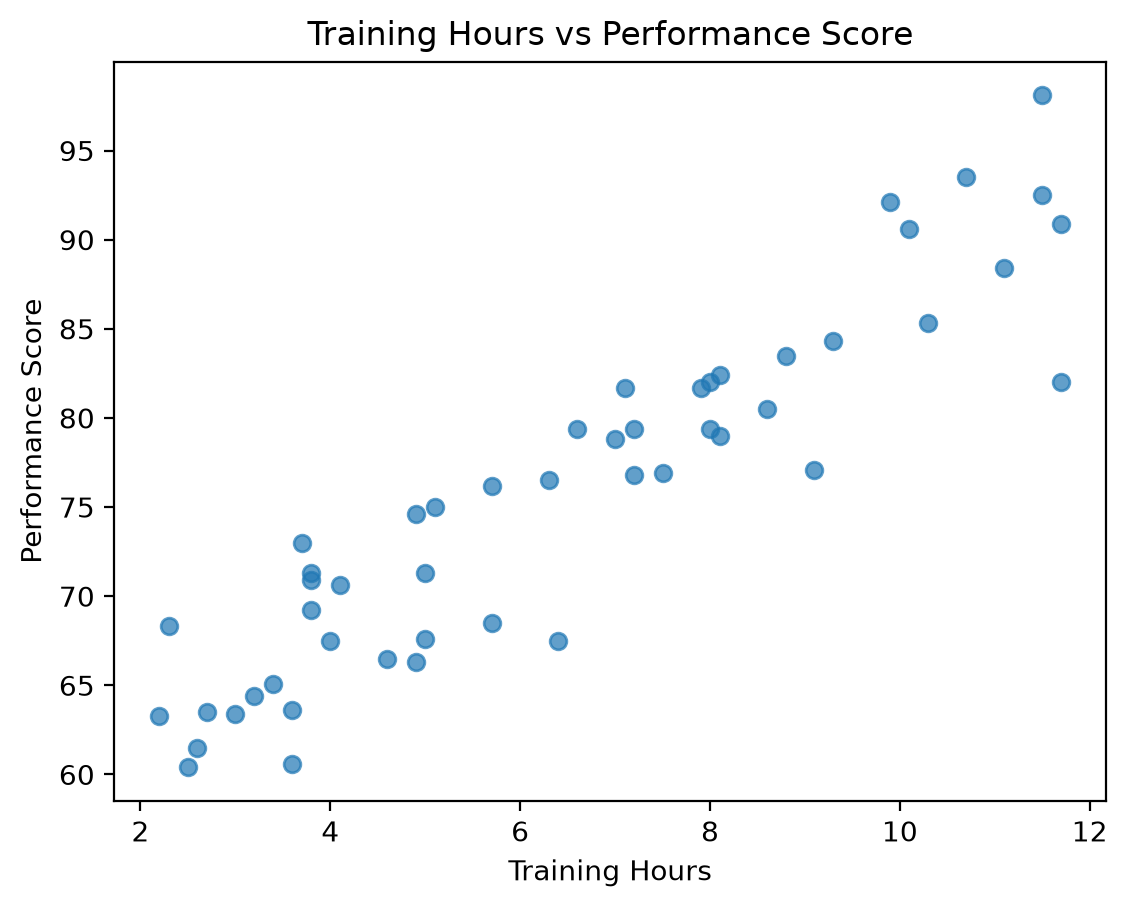

In [2]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

plt.scatter(
    athletes["training_hours"],
    athletes["performance_score"],
    alpha=0.7
)

plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.title("Training Hours vs Performance Score")

plt.show()


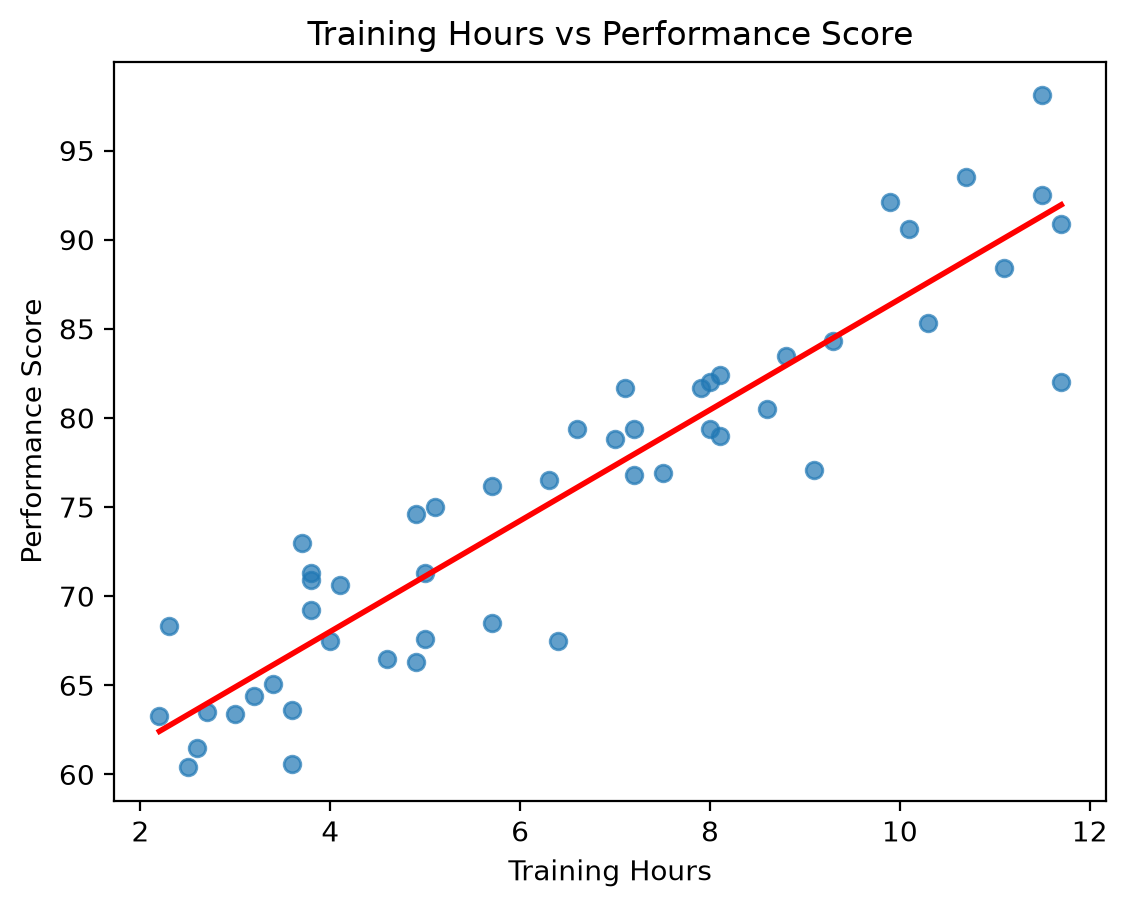

In [3]:
# 회귀선 추가 그래프

import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=athletes,
    x="training_hours",
    y="performance_score",
    scatter_kws={
        "alpha": 0.7
    },
    line_kws={
        "linewidth": 2,
        "color":"red"
    },
    ci=None
)

plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.title("Training Hours vs Performance Score")

plt.show()


> ### **1-4 ) 훈련시간과 회복점수의 관계**

#### "훈련시간과 회복점수의 관계를 산점도와 회귀선으로 확인"

Text(0.5, 1.0, 'Training Hours vs Recovery Score')

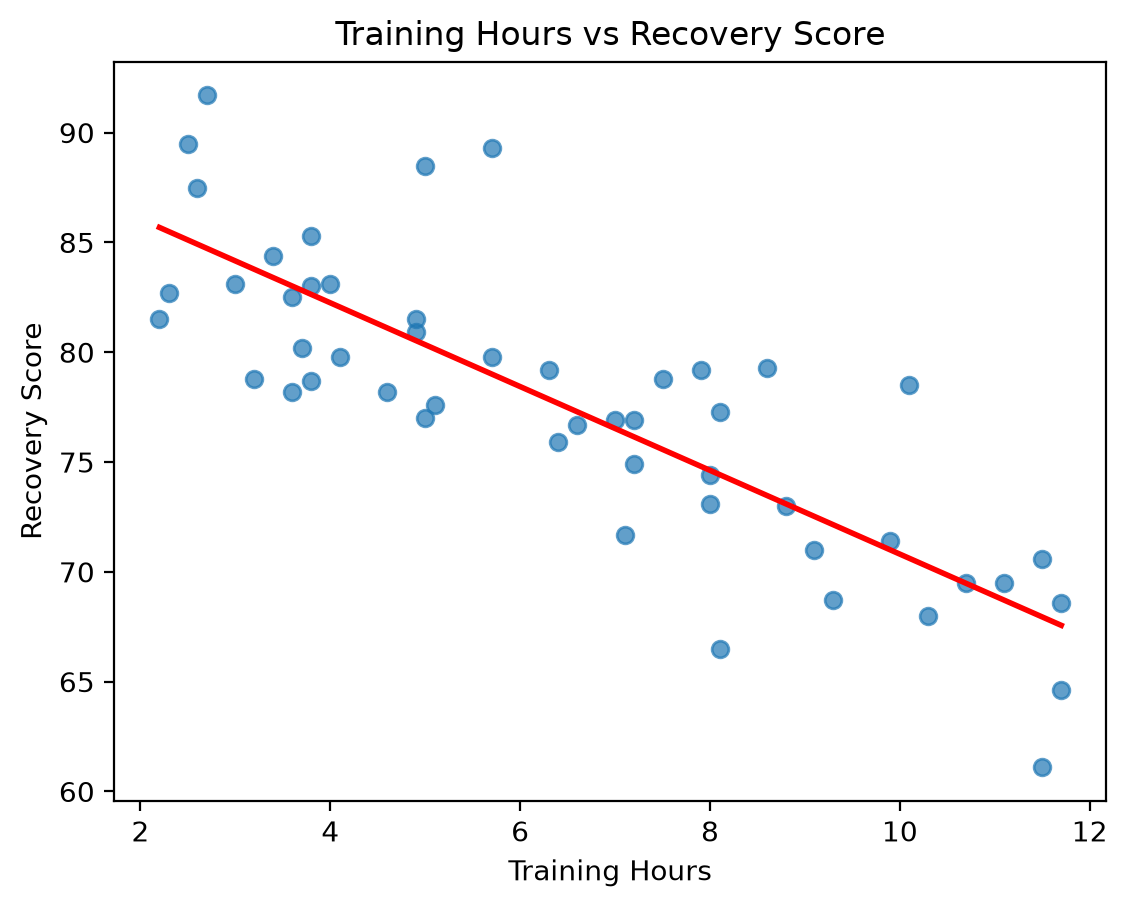

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=athletes,
    x="training_hours",
    y="recovery_score",
    scatter_kws={
        "alpha": 0.7
    },
    line_kws={
        "linewidth": 2,
        "color":"red"
    },
    ci=None
)

plt.xlabel("Training Hours")
plt.ylabel("Recovery Score")
plt.title("Training Hours vs Recovery Score")

## 3. 상관관계 히트맵(Correlation Heatmap)


> ## **3-1 ) corr()로 상관계수 행렬 생성**

In [5]:
numeric_df = athletes[
    [
        "training_hours",
        "performance_score",
        "recovery_score",
        "sleep_hours"
    ]
]

corr = numeric_df.corr()

corr.round(3)

,training_hours,performance_score,recovery_score,sleep_hours
training_hours,1.000,0.926,-0.825,0.031
performance_score,0.926,1.000,-0.800,-0.048
recovery_score,-0.825,-0.800,1.000,-0.011
sleep_hours,0.031,-0.048,-0.011,1.000


> ## **3-3 ) 상관관계 히트맵 생성**



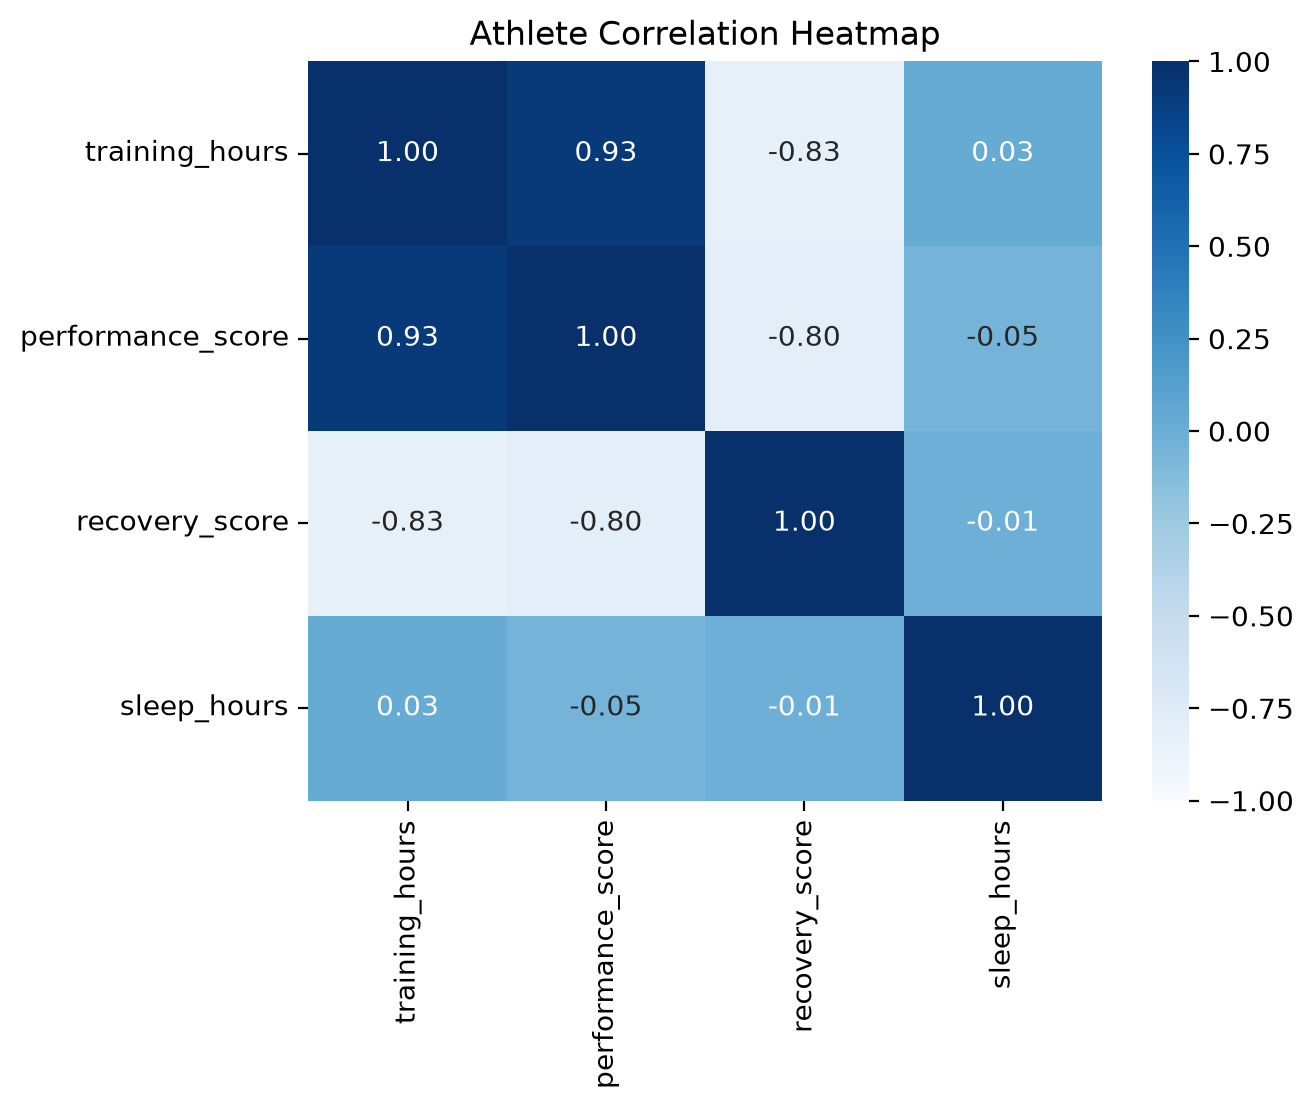

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    "Athlete Correlation Heatmap"
)

plt.show()

#### 히트맵 꾸미기

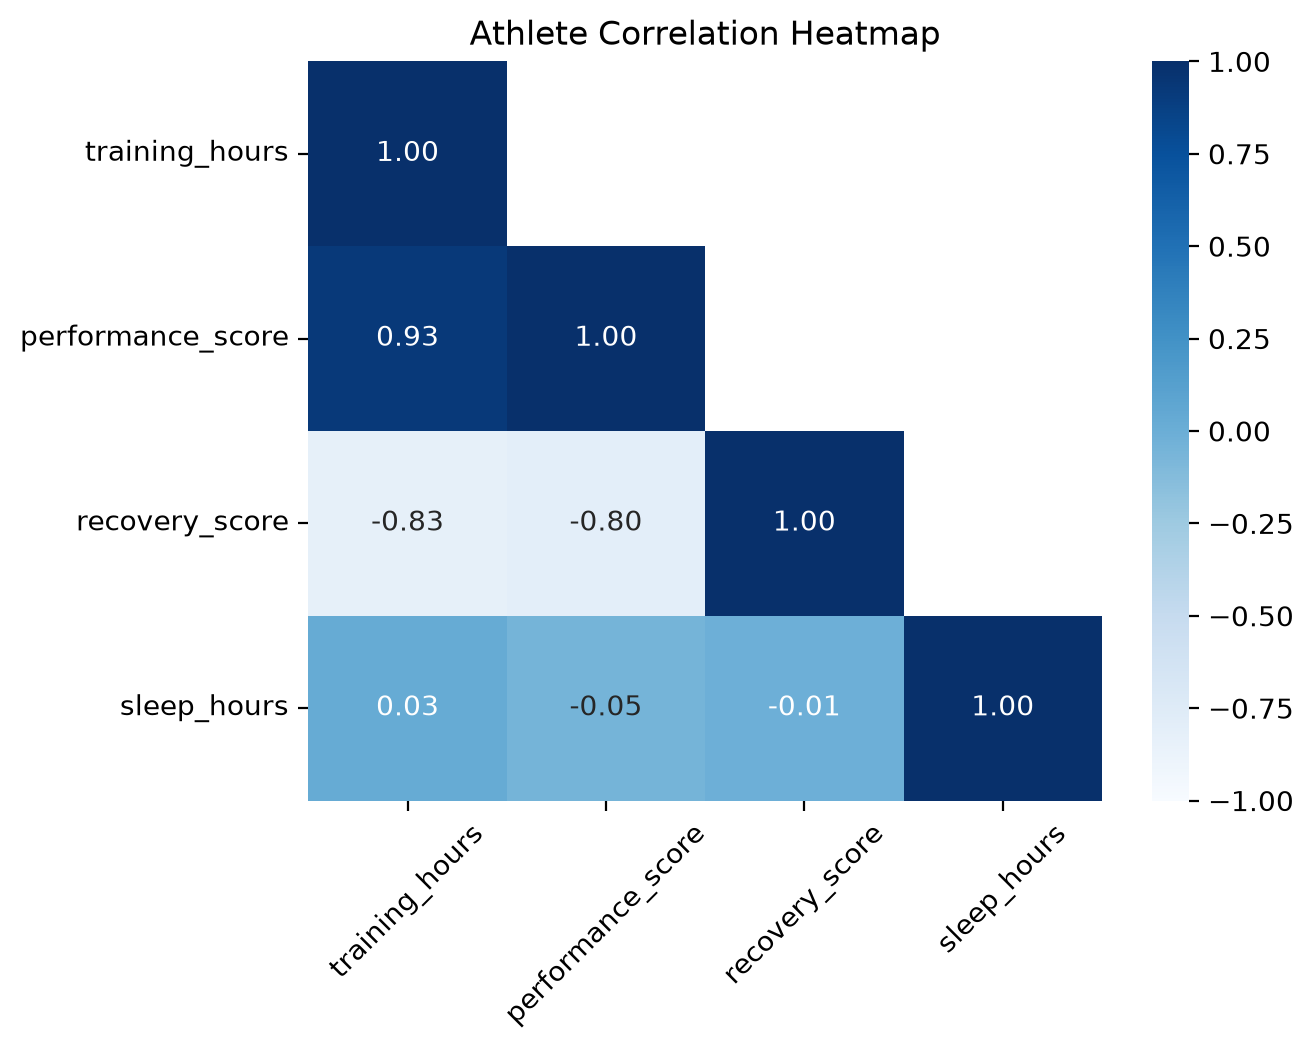

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 대각선 위쪽만 가리기
# k=1 → 대각선(1.00)은 남김
mask = np.triu(
    np.ones_like(corr, dtype=bool),
    k=1
)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Athlete Correlation Heatmap")
plt.xticks(rotation=45)

plt.show()